# Signal Model

This notebook introduces the narrowband array signal model used for direction-of-arrival (DoA) estimation in FMCW radar.

After range and Doppler processing, a selected range–Doppler cell contains one complex sample from each antenna channel.  
For far-field targets, the received wavefront can be approximated as a **planar wave**, so the phase difference across the array depends on the source direction and the array geometry.

A **snapshot** is the vector of complex samples measured simultaneously across all antenna elements for one observation.

## Snapshot Model

For an array with $M$ antenna elements and $K$ incident sources, one snapshot is modeled as

$$
\mathbf{x} = \mathbf{A}\mathbf{s} + \mathbf{n}.
$$

where

- $\mathbf{x} \in \mathbb{C}^{M \times 1}$ — received snapshot vector across the array,
- $\mathbf{A} \in \mathbb{C}^{M \times K}$ — array manifold matrix,
- $\mathbf{s} \in \mathbb{C}^{K \times 1}$ — complex source signal vector,
- $\mathbf{n} \in \mathbb{C}^{M \times 1}$ — additive noise vector.

The array manifold matrix is formed from the steering vectors of all incident sources:

$$
\mathbf{A}
=
\begin{bmatrix}
\mathbf{a}(\theta_1) &
\mathbf{a}(\theta_2) &
\cdots &
\mathbf{a}(\theta_K)
\end{bmatrix}.
$$

Each column $\mathbf{a}(\theta_k)$ describes the phase progression across the array for a source arriving from direction $\theta_k$.

## Steering Vector

A **uniform linear array (ULA)** consists of equally spaced receiving elements arranged along a straight line.

The distance between adjacent elements is the **inter-element spacing** $d$.

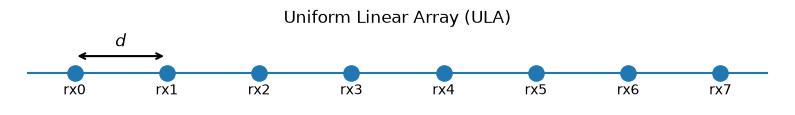

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Simple ULA sketch
M = 8
d = 1.0  # normalized spacing for visualization

x = np.arange(M) * d
y = np.zeros(M)

fig, ax = plt.subplots(figsize=(10, 2.5))

# Array axis
ax.plot([x[0] - 0.5*d, x[-1] + 0.5*d], [0, 0], linewidth=1.5)

# Antenna elements
ax.scatter(x, y, s=120)

for i, xi in enumerate(x):
    ax.text(xi, -0.12, f"rx{i}", ha="center", va="top", fontsize=10)

# Bidirectional spacing arrow
ax.annotate(
    "",
    xy=(x[1], 0.18),
    xytext=(x[0], 0.18),
    arrowprops=dict(arrowstyle="<->", lw=1.5)
)
ax.text((x[0] + x[1]) / 2, 0.24, r"$d$", ha="center", va="bottom", fontsize=12)

ax.set_title("Uniform Linear Array (ULA)")
ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(x[0] - 0.7*d, x[-1] + 0.7*d)
ax.set_ylim(-0.35, 0.45)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

For a ULA with inter-element spacing $d$, the steering vector for a plane wave arriving from angle $\theta$ is

$$
\mathbf{a}(\theta)
=
\begin{bmatrix}
1 \\
e^{-jkd\sin\theta} \\
e^{-j2kd\sin\theta} \\
\vdots \\
e^{-j(M-1)kd\sin\theta}
\end{bmatrix},
$$

where

- $M$ — number of antenna elements,
- $d$ — spacing between adjacent elements,
- $\theta$ — direction of arrival measured from broadside,
- $k = \dfrac{2\pi}{\lambda}$ — wavenumber,
- $\lambda$ — wavelength,
- $j = \sqrt{-1}$ — imaginary unit.

Equivalently, the $m$-th steering-vector entry is

$$
[\mathbf{a}(\theta)]_m = e^{-jmkd\sin\theta},
\qquad m = 0,1,\ldots,M-1.
$$

For half-wavelength spacing, $d = \lambda/2$, the phase increment between adjacent elements becomes

$$
\Delta \phi = -\pi \sin\theta.
$$

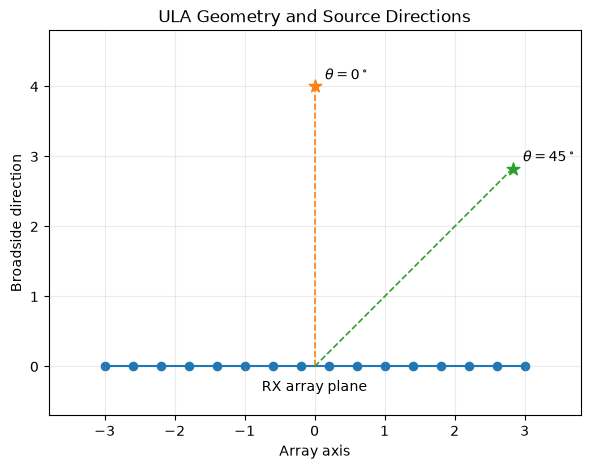

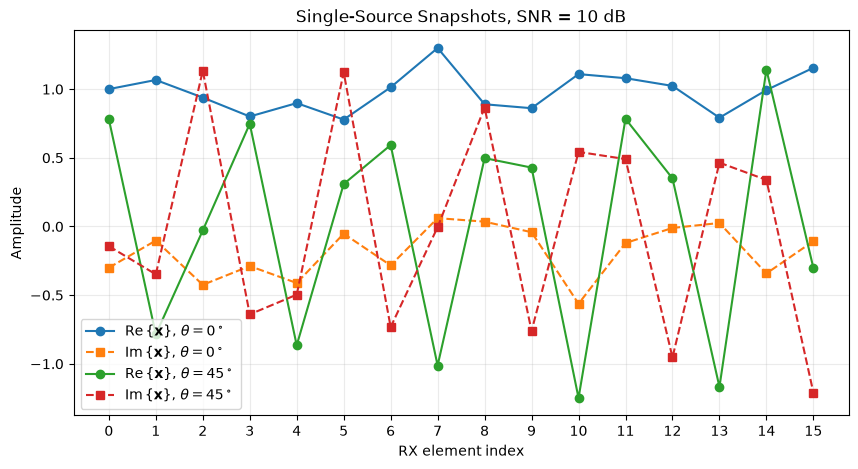

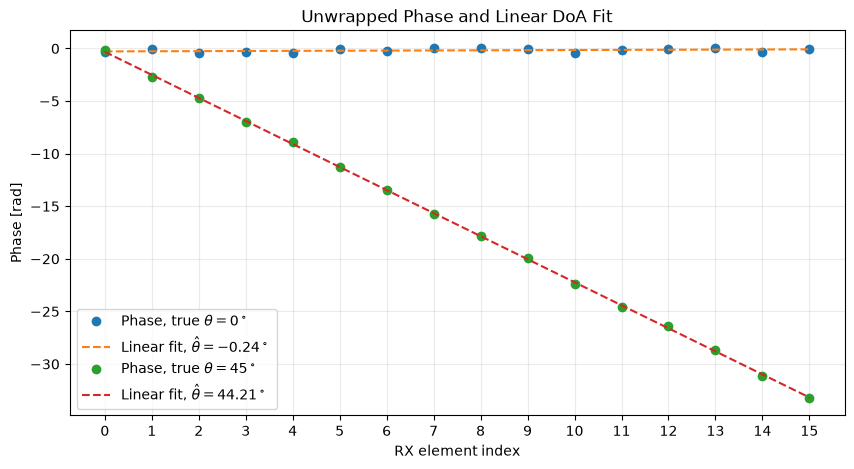

True DoA:   0.00 deg | Phase slope:   0.0130 rad/element | Estimated DoA:  -0.24 deg
True DoA:  45.00 deg | Phase slope:  -2.1907 rad/element | Estimated DoA:  44.21 deg


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
M = 16
wavelength = 1.0
d = wavelength / 2
k = 2 * np.pi / wavelength

snr_db = 10.0
angles_deg = [0.0, 45.0]

m = np.arange(M)
rng = np.random.default_rng(7)


# ------------------------------------------------------------
# Signal-model functions
# ------------------------------------------------------------
def steering_vector(theta_deg):
    """ULA steering vector for an angle measured from broadside."""
    theta = np.deg2rad(theta_deg)

    return np.exp(
        -1j * k * d * m * np.sin(theta)
    )


def noisy_snapshot(theta_deg, snr_db):
    """Generate one noisy single-source snapshot."""
    x_clean = steering_vector(theta_deg)

    signal_power = np.mean(np.abs(x_clean) ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))

    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(M)
        + 1j * rng.standard_normal(M)
    )

    return x_clean + noise


# ------------------------------------------------------------
# Geometry sketch
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

array_x = np.linspace(-3.0, 3.0, M)
array_y = np.zeros(M)
array_center = np.array([0.0, 0.0])

ax.plot(array_x, array_y, linewidth=1.5)
ax.scatter(array_x, array_y, s=35)

ax.text(
    0.0,
    -0.35,
    "RX array plane",
    ha="center",
)

source_range = 4.0

for theta_deg in angles_deg:
    theta = np.deg2rad(theta_deg)

    source_position = np.array(
        [
            source_range * np.sin(theta),
            source_range * np.cos(theta),
        ]
    )

    ax.scatter(
        source_position[0],
        source_position[1],
        s=90,
        marker="*",
    )

    ax.plot(
        [array_center[0], source_position[0]],
        [array_center[1], source_position[1]],
        linestyle="--",
        linewidth=1.2,
    )

    ax.text(
        source_position[0] + 0.15,
        source_position[1] + 0.10,
        rf"$\theta={theta_deg:.0f}^\circ$",
    )

ax.set_title("ULA Geometry and Source Directions")
ax.set_xlabel("Array axis")
ax.set_ylabel("Broadside direction")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.8, 3.8)
ax.set_ylim(-0.7, 4.8)
ax.grid(True, alpha=0.25)

plt.show()


# ------------------------------------------------------------
# Generate both snapshots and estimate both DoAs
# ------------------------------------------------------------
snapshots = {}
phases = {}
phase_fits = {}
estimates = {}

for theta_deg in angles_deg:
    x = noisy_snapshot(theta_deg, snr_db)

    phase = np.unwrap(np.angle(x))

    slope, intercept = np.polyfit(
        m,
        phase,
        1,
    )

    phase_fit = slope * m + intercept

    sin_theta_est = np.clip(
        -slope / (k * d),
        -1.0,
        1.0,
    )

    theta_est_deg = np.rad2deg(
        np.arcsin(sin_theta_est)
    )

    snapshots[theta_deg] = x
    phases[theta_deg] = phase
    phase_fits[theta_deg] = phase_fit
    estimates[theta_deg] = {
        "slope": slope,
        "theta_deg": theta_est_deg,
    }


# ------------------------------------------------------------
# Real and imaginary parts of both snapshots
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

for theta_deg in angles_deg:
    x = snapshots[theta_deg]

    ax.plot(
        m,
        x.real,
        "o-",
        label=rf"$\operatorname{{Re}}\{{\mathbf{{x}}\}}$, "
              rf"$\theta={theta_deg:.0f}^\circ$",
    )

    ax.plot(
        m,
        x.imag,
        "s--",
        label=rf"$\operatorname{{Im}}\{{\mathbf{{x}}\}}$, "
              rf"$\theta={theta_deg:.0f}^\circ$",
    )

ax.set_title(
    rf"Single-Source Snapshots, SNR = {snr_db:.0f} dB"
)
ax.set_xlabel("RX element index")
ax.set_ylabel("Amplitude")
ax.set_xticks(m)
ax.grid(True, alpha=0.25)
ax.legend()

plt.show()


# ------------------------------------------------------------
# Unwrapped phases and linear fits of both snapshots
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

for theta_deg in angles_deg:
    theta_est_deg = estimates[theta_deg]["theta_deg"]

    ax.plot(
        m,
        phases[theta_deg],
        "o",
        label=rf"Phase, true $\theta={theta_deg:.0f}^\circ$",
    )

    ax.plot(
        m,
        phase_fits[theta_deg],
        "--",
        label=rf"Linear fit, "
              rf"$\hat{{\theta}}={theta_est_deg:.2f}^\circ$",
    )

ax.set_title("Unwrapped Phase and Linear DoA Fit")
ax.set_xlabel("RX element index")
ax.set_ylabel("Phase [rad]")
ax.set_xticks(m)
ax.grid(True, alpha=0.25)
ax.legend()

plt.show()


# ------------------------------------------------------------
# Numerical results
# ------------------------------------------------------------
for theta_deg in angles_deg:
    slope = estimates[theta_deg]["slope"]
    theta_est_deg = estimates[theta_deg]["theta_deg"]

    print(
        f"True DoA: {theta_deg:6.2f} deg | "
        f"Phase slope: {slope:8.4f} rad/element | "
        f"Estimated DoA: {theta_est_deg:6.2f} deg"
    )

For a single dominant source, the phase progression across a calibrated ULA is approximately linear, so fitting a straight line to the unwrapped phase provides a simple DoA estimate.

This idea is useful for intuition, but in practical DoA estimation one usually relies on multiple snapshots and covariance-based methods, which are more robust in noise and in multi-source scenarios.